In [1]:
# import libraries needed in work book
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# Will work on dynamically setting filepath soon
file_path = "csv/cleaned_csv/pp-test-1000prems_cleaned_data.csv"

df = pd.read_csv(file_path, index_col=0)
# clean up date
df['date_of_transfer'] = pd.to_datetime(df['date_of_transfer'], errors='coerce') # turn date into datetime value

In [2]:
# Add a Year Col, then using the year col add an year average price column
average_type = 'mean'
df['year_of_transfer'] = df['date_of_transfer'].dt.year # add a column with just the year for agg purposes. dt.year gives me an int. dt.strftime('%Y') gives a string
df['year_avg_sale'] = df.groupby('year_of_transfer')['price'].transform(average_type)

average_type = average_type.capitalize() # for the title of the graph

In [3]:
df_plot = df.copy()

In [4]:
df_plot = df_plot.sort_values('year_of_transfer')

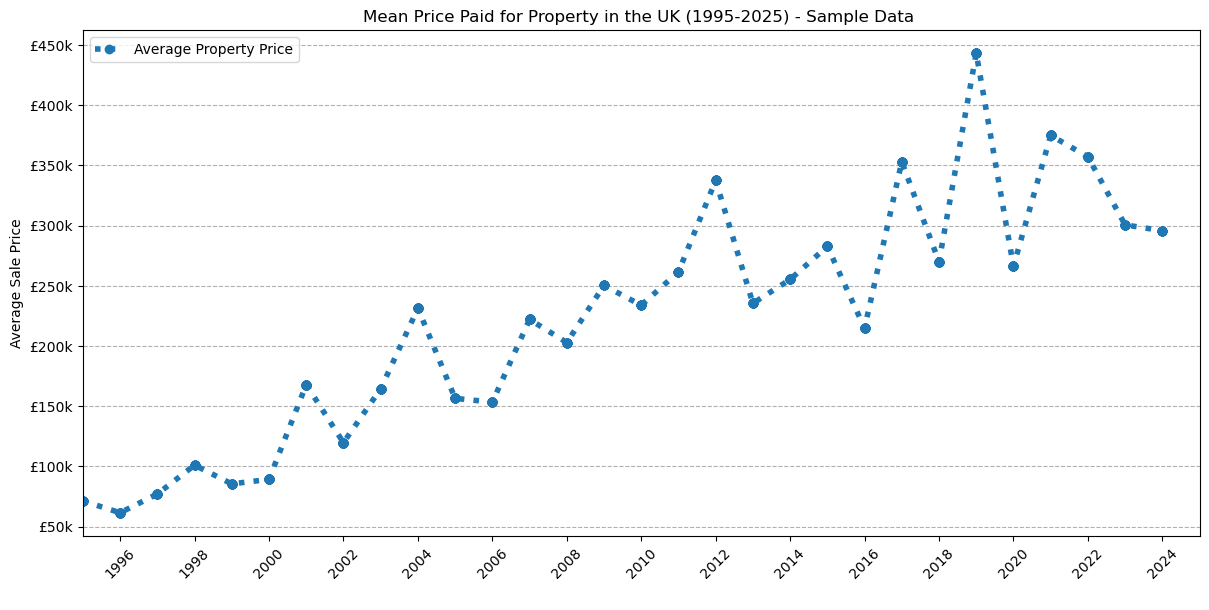

In [25]:
fig, ax = plt.subplots()

df_plot.plot(
    kind='line',
    linewidth=4, 
    linestyle=':',
    marker='o',
    markersize=6,
    x='year_of_transfer', 
    y='year_avg_sale', 
    label="Average Property Price",
    figsize=(12,6), 
    ax=ax)



ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'£{int(y/1000)}k')) # Formats the Y ticks to £100k etc
plt.locator_params(axis='x', nbins=19) 
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle="--") #Grid & linestyle of grid.
plt.xlim(1995, 2025)
plt.legend(title='', loc='upper left')
plt.xlabel('   ')
plt.ylabel('Average Sale Price')
plt.title(f'{average_type} Price Paid for Property in the UK (1995-2025) - Sample Data ')

plt.show()


In [6]:
df.head(10)

,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category_type,record_status,year_of_transfer,year_avg_sale
index,,,,,,,,,,,,,,,,,,
NaN,{D8127CD0-5A78-4413-8F5A-CD7E2C319F44},35000,1995-11-24,LA3 1PT,S,N,F,7,Unnamed: 8,OXCLIFFE AVENUE,HEYSHAM,MORECAMBE,LANCASTER,LANCASHIRE,A,A.1,1995,71391.666667
28281846.0,{E7B085FC-8958-7E31-E053-6C04A8C0E67F},485000,2022-05-27,NW8 0BH,F,N,L,SANDBOURNE,FLAT 5,ABBEY ROAD,NaN,LONDON,CAMDEN,GREATER LONDON,A,A,2022,357141.116279
19126276.0,{70F13FA4-FC4C-4367-BB61-4ADD5CA1B0C1},158995,2014-11-28,NE33 5EE,S,N,F,8,NaN,GARDEN GATE DRIVE,NaN,SOUTH SHIELDS,SOUTH TYNESIDE,TYNE AND WEAR,A,A,2014,255276.428571
11833278.0,{BBF175F8-5D4E-4BF0-893A-024F9B58F8B0},165995,2005-08-22,BB5 6NW,D,Y,L,3,NaN,HYACINTH AVENUE,HUNCOAT,ACCRINGTON,HYNDBURN,LANCASHIRE,A,A,2005,156537.900000
16809948.0,{16AE7E0B-769A-4C68-8482-60D9CF4D75F1},163200,2010-03-10,CH5 4LE,T,N,F,24,NaN,UPLANDS AVENUE,CONNAHS QUAY,DEESIDE,FLINTSHIRE,FLINTSHIRE,A,A,2010,233858.636364
19403399.0,{F4E9FD11-10D6-4A5B-BDE7-6391FC3EE220},550000,2014-02-17,TW10 5DU,F,N,L,593B,NaN,UPPER RICHMOND ROAD WEST,NaN,RICHMOND,RICHMOND UPON THAMES,GREATER LONDON,A,A,2014,255276.428571
5367176.0,{D11708A8-8452-4B6E-93EB-EB4BC74536E2},120000,2000-09-05,YO41 5NN,D,N,F,33,NaN,MAIN STREET,WILBERFOSS,YORK,EAST RIDING OF YORKSHIRE,EAST RIDING OF YORKSHIRE,A,A,2000,89314.903846
12084031.0,{36881E88-2272-4295-BED3-50ADA39DE523},247950,2005-09-08,TA9 4RW,D,N,F,2,NaN,GRANGE PADDOCK,MARK,HIGHBRIDGE,SEDGEMOOR,SOMERSET,A,A,2005,156537.900000
19337940.0,{21E5FEB6-B19D-2439-E050-A8C06205342E},147300,2014-05-30,DN3 1BE,S,N,F,10,NaN,CHURCH ROAD,BARNBY DUN,DONCASTER,DONCASTER,SOUTH YORKSHIRE,B,A,2014,255276.428571
